In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

In [10]:
import pandas as pd

df = pd.read_csv('housing_data_final.csv')

train_df = df.sample(frac=0.8, random_state=42)

test_df = df.drop(train_df.index)

X_train = train_df.drop('price_scaled', axis=1)
y_train = train_df['price_scaled']

X_test = test_df.drop('price_scaled', axis=1)
y_test = test_df['price_scaled']

print(f"Total entries: {len(df)}")
print(f"Training set: {len(X_train)} rows")
print(f"Testing set: {len(X_test)} rows")

Total entries: 545
Training set: 436 rows
Testing set: 109 rows


In [11]:
import numpy as np

def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost_sum = 0

    for i in range(m):
        f_wb = np.dot(x[i], w) + b
        cost = (f_wb - y[i])**2
        cost_sum = cost_sum + cost

    total_cost = (1 / (2 * m)) * cost_sum

    return total_cost

In [12]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = np.zeros(x.shape[1])
    dj_db = 0

    for i in range(m):
        f_wb = np.dot(x[i], w) + b
        err = f_wb - y[i]
        dj_dw = dj_dw + (err * x[i])
        dj_db = dj_db + err

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

In [37]:
import math
import matplotlib.pyplot as plt
import numpy as np

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    j_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        current_cost = cost_function(x, y, w, b)

        if i < 100000:
            j_history.append(current_cost)
            p_history.append([w, b])

        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4}: Cost {current_cost:0.2e} ",
                  f"dj_dw: {np.mean(dj_dw): 0.3e}, dj_db: {dj_db: 0.3e}")

    plt.figure()
    plt.plot(j_history, color='purple')
    plt.title("Learning Curve (Cost Reduction)")
    plt.xlabel("Iteration Number")
    plt.ylabel("Cost (MSE)")
    plt.grid(True)
    plt.savefig('learning_curve.png')
    print("Learning curve saved as learning_curve.png")
    plt.show()

    return w, b, j_history, p_history

Iteration    0: Cost 4.82e-01  dj_dw: -2.377e-01, dj_db:  1.416e-02
Iteration  100: Cost 2.84e-01  dj_dw: -4.575e-02, dj_db:  1.007e-01
Iteration  200: Cost 2.45e-01  dj_dw: -2.248e-02, dj_db:  8.240e-02
Iteration  300: Cost 2.29e-01  dj_dw: -1.361e-02, dj_db:  7.219e-02
Iteration  400: Cost 2.20e-01  dj_dw: -9.671e-03, dj_db:  6.549e-02
Iteration  500: Cost 2.12e-01  dj_dw: -7.551e-03, dj_db:  6.055e-02
Iteration  600: Cost 2.07e-01  dj_dw: -6.202e-03, dj_db:  5.661e-02
Iteration  700: Cost 2.03e-01  dj_dw: -5.245e-03, dj_db:  5.332e-02
Iteration  800: Cost 1.99e-01  dj_dw: -4.523e-03, dj_db:  5.048e-02
Iteration  900: Cost 1.96e-01  dj_dw: -3.960e-03, dj_db:  4.797e-02
Learning curve saved as learning_curve.png


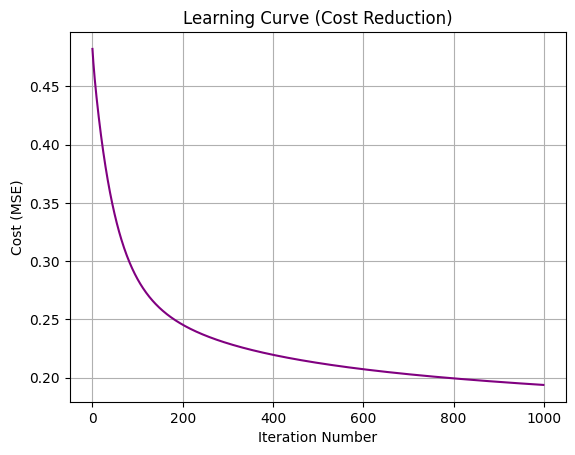

Final Weights: [-0.15542139  0.30666442  0.27001362 -0.17670272  0.19884303  0.1976064
  0.40185799  0.17020909  0.11535958  0.42921775]
Final Bias: -0.6713
First 5 Predictions: [-0.77328937 -0.94396819 -0.12944835 -1.19388054 -0.76601422]
First 5 Actual: [-1.61284504 -1.50057196 -1.35461697 -1.35087454 -1.27602582]


In [38]:
m, n = X_train.shape
initial_w = np.zeros(n)
initial_b = 0.
iterations = 1000
alpha = 0.01

# Convert DataFrames/Series to NumPy arrays
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy()

w_final, b_final, j_hist, p_hist = gradient_descent(
    X_train_np, y_train_np, initial_w, initial_b, alpha, iterations, compute_cost, compute_gradient
)

print(f"Final Weights: {w_final}")
print(f"Final Bias: {b_final:0.4f}")

test_predictions = np.dot(X_test_np, w_final) + b_final
print(f"First 5 Predictions: {test_predictions[:5]}")

print(f"First 5 Actual: {y_test_np[:5]}")

In [20]:
import numpy as np

test_predictions = np.dot(X_test, w_final) + b_final
mae = np.mean(np.abs(test_predictions - y_test))

ss_res = np.sum((y_test - test_predictions)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"Mean Absolute Error (Standardized): {mae:.4f}")
print(f"R-squared Score: {r2:.4f}")

Mean Absolute Error (Standardized): 0.5786
R-squared Score: 0.4813


In [23]:
df_original = pd.read_csv('housing_data_final.csv')
area_mean = df_original['area_scaled'].mean()
area_std = df_original['area_scaled'].std()
price_mean = df_original['price_scaled'].mean()
price_std = df_original['price_scaled'].std()

In [24]:
my_house_features = {
    'area': 5000,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 'yes',
    'guestroom': 'no',
    'basement': 'yes',
    'airconditioning': 'yes',
    'parking': 2,
    'furnishingstatus': 'semi-furnished'
}

In [25]:
furnishing_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
binary_map = {'yes': 1, 'no': 0}

In [27]:
scaled_area = (my_house_features['area'] - area_mean) / area_std
f_status = furnishing_map[my_house_features['furnishingstatus']]
m_road = binary_map[my_house_features['mainroad']]
g_room = binary_map[my_house_features['guestroom']]
b_ment = binary_map[my_house_features['basement']]
a_cond = binary_map[my_house_features['airconditioning']]

In [28]:
X_input = np.array([
    my_house_features['bedrooms'],
    my_house_features['bathrooms'],
    my_house_features['stories'],
    m_road, g_room, b_ment, a_cond,
    my_house_features['parking'],
    f_status,
    scaled_area
])

In [29]:
price_scaled_pred = np.dot(X_input, w_final) + b_final

In [30]:
actual_price_pred = (price_scaled_pred * price_std) + price_mean

print(f"Predicted Price for your house: ${actual_price_pred:,.2f}")

Predicted Price for your house: $2,146.98


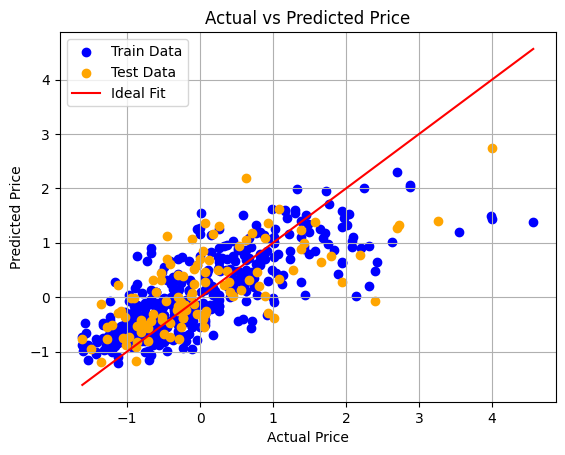

<Figure size 640x480 with 0 Axes>

In [32]:
# Calculate predictions for training data
y_train_pred = np.dot(X_train_np, w_final) + b_final

# test_predictions already holds predictions for X_test_np

plt.scatter(y_train_np, y_train_pred, c='blue', label='Train Data')
plt.scatter(y_test_np, test_predictions, c='orange', label='Test Data')

limit=[min(y_train_np.min(), y_test_np.min()), max(y_train_np.max(), y_test_np.max())]
plt.plot(limit, limit, c='red', label='Ideal Fit')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.legend()
plt.grid(True)
plt.show()
plt.savefig('DBMS.png',dpi=300)